# Step 1: Pb isotope clustering

In [1]:
xf = "206Pb_207Pb_mean"
yf = "208Pb_207Pb_mean"
xerr = xf.replace("mean", "2SE")
yerr = yf.replace("mean", "2SE")

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

## Load & preprocess data

In [3]:
raw_data = pd.read_csv("data/Pb_data.csv", comment="#")

In [4]:
xerr_threshold_value = round(raw_data[xerr].quantile(0.58), 4)
yerr_threshold_value = round(raw_data[yerr].quantile(0.58), 4)

training_data_mask = (raw_data[xerr] < xerr_threshold_value) & (
    raw_data[yerr] < yerr_threshold_value
)

print(xerr, "threshold =", xerr_threshold_value)
print(yerr, "threshold =", yerr_threshold_value)
print("data remaining:", round(sum(training_data_mask) / len(raw_data) * 100, 1), "%")

206Pb_207Pb_2SE threshold = 0.0004
208Pb_207Pb_2SE threshold = 0.0006
data remaining: 53.5 %


In [5]:
X_train_unscaled = raw_data.loc[training_data_mask, [xf, yf]].to_numpy(dtype=np.float32)

### Normalise the data

In [6]:
from sklearn.preprocessing import RobustScaler

scaler = RobustScaler()
scaler.fit(X=X_train_unscaled)

X_train_scaled = scaler.transform(X_train_unscaled)

### Remove outliers with OPTICS

In [7]:
from sklearn.cluster import OPTICS

opt = OPTICS(min_samples=15, xi=0.01).fit(X_train_scaled)

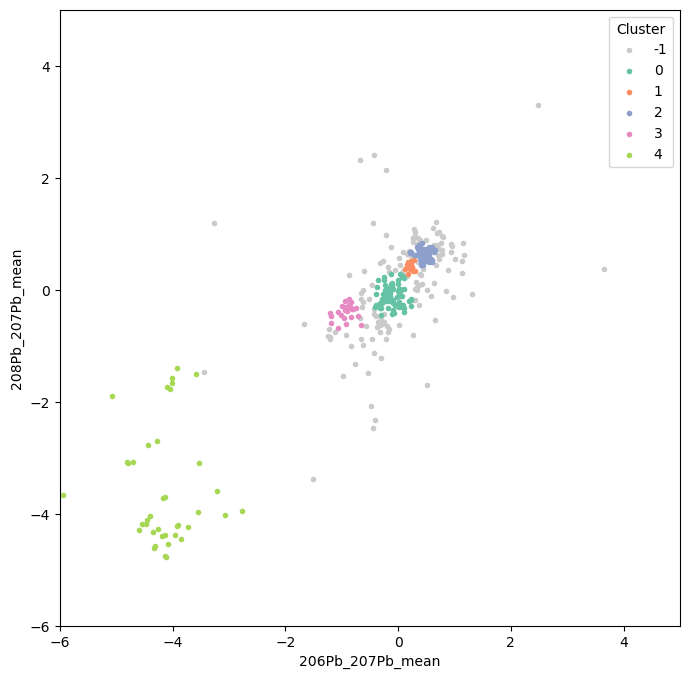

In [8]:
labels = opt.labels_.astype(str)

plt.figure(figsize=(8, 8))
for cluster in np.unique(labels):
    subset = X_train_scaled[labels == cluster]
    color = '#cacaca' if cluster == '-1' else plt.cm.Set2(int(cluster))
    plt.scatter(subset[:, 0], subset[:, 1], label=cluster, marker='.', color=color)

plt.xlim(-6, 5)
plt.ylim(-6, 5)
plt.xlabel(xf)
plt.ylabel(yf)
plt.legend(title='Cluster')
plt.show()

In [9]:
print("outliers:", np.sum(opt.labels_ == -1))

outliers: 130


In [10]:
X_train = X_train_scaled[opt.labels_ > -1]
X_train_index = raw_data.loc[training_data_mask, "spot_id"].loc[opt.labels_ > -1]

## Fit the GMM

In [11]:
from sklearn.mixture import GaussianMixture

gmm = GaussianMixture(
    n_components=5,
    covariance_type="full",
    max_iter=1000,
    n_init=100,
    init_params="k-means++",
    random_state=0,
).fit(X_train)

cluster = gmm.predict(X_train)

rescaled_X_train = scaler.inverse_transform(X_train)

clustered = pd.DataFrame(
    {"spot_id": X_train_index, 
     xf: rescaled_X_train[:, 0],
     yf: rescaled_X_train[:, 1],
     "cluster": cluster}
)

### Plot the clustered data

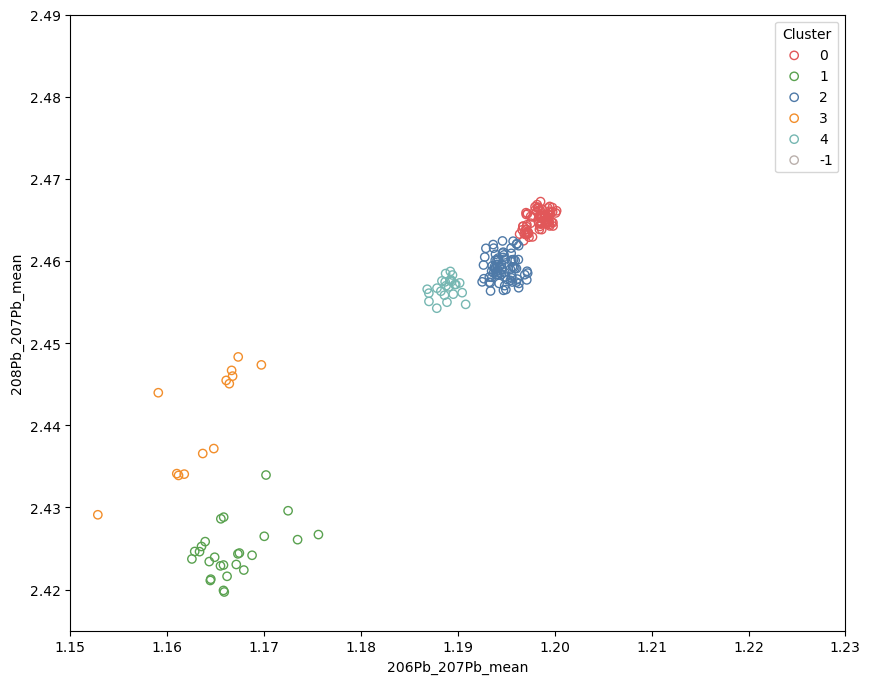

In [12]:
custom_palette = {
    "0": "#e15759",
    "1": "#59a14f",
    "2": "#4e79a7",
    "3": "#f28e2b",
    "4": "#76b7b2",
    "-1": "#bab0ac",
}

plt.figure(figsize=(10, 8))
for cluster, color in custom_palette.items():
    subset = clustered[clustered['cluster'].astype(str) == cluster]
    plt.scatter(subset[xf], subset[yf], label=cluster, color=color, edgecolor=None, linewidth=1, marker='o', facecolors='none')

plt.xlim(1.15, 1.23)
plt.ylim(2.415, 2.49)
plt.xlabel(xf)
plt.ylabel(yf)
plt.legend(title='Cluster')
plt.show()

## Export the model

In [13]:
import pickle as pkl

with open("Pb_RobustScaler.pkl", "wb") as f:
    pkl.dump(scaler, f)
with open("Pb_GMM.pkl", "wb") as f:
    pkl.dump(gmm, f)